# Music Recommendation System

This notebook implements a Music Recommendation System using the Spotify Tracks Dataset (`dataset.csv`).

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Set styling
sns.set_theme(style="whitegrid")

In [52]:
df = pd.read_csv('dataset.csv')
print(f"Loaded {df.shape[0]} tracks with {df.shape[1]} features.")
df.head()

Loaded 114000 tracks with 21 features.


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [53]:
df.shape

(114000, 21)

In [54]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [56]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [57]:
df[df["artists"].isnull()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [58]:
df.drop(65900, inplace=True)

In [59]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df[df.duplicated(subset=["track_name", "artists"])]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18,18,2qLMf6TuEC3ruGJg4SMMN6,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,68,189613,False,0.625,0.414,...,-8.700,1,0.0369,0.29400,0.000000,0.1510,0.6690,130.088,4,acoustic
20,20,3S0OXQeoh0w6AY8WQVckRW,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,75,242946,False,0.703,0.444,...,-9.331,1,0.0417,0.55900,0.000000,0.0973,0.7120,150.960,4,acoustic
22,22,5TvE3pk05pyFIGdSY9j4DJ,A Great Big World;Christina Aguilera,Is There Anybody Out There? - Track by Track C...,Say Something,70,229400,False,0.407,0.147,...,-8.822,1,0.0355,0.85700,0.000003,0.0913,0.0765,141.284,3,acoustic
28,28,5QAMZTM5cmLg3fHX9ZbTZi,Jason Mraz,Christmas Time,Winter Wonderland,0,131760,False,0.620,0.309,...,-9.209,1,0.0495,0.78800,0.000000,0.1460,0.6640,145.363,4,acoustic
29,29,2qESE1ZeWly7I3YjyTXmXh,Jason Mraz,Perfect Christmas Hits,Winter Wonderland,0,131760,False,0.620,0.309,...,-9.209,1,0.0495,0.78800,0.000000,0.1460,0.6640,145.363,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113845,113845,5oyYmgnwGZ74992OLfYD2f,Hillsong Worship;Brooke Ligertwood,Awake,King Of Kings - Live at Hillsong Conference,40,291565,False,0.454,0.427,...,-8.049,1,0.0290,0.02050,0.000000,0.6900,0.1840,135.887,4,world-music
113882,113882,7lYdF3SC4SCJPg5kROvXWx,Bryan & Katie Torwalt,I've Got Good News (Live) [Deluxe],Good News - Live,23,266632,False,0.473,0.474,...,-9.175,1,0.0558,0.39500,0.000000,0.1630,0.2510,140.746,4,world-music
113917,113917,4r0ETFFJMBSQ0Z3ntuMDP2,Hillsong Worship;Mi-kaisha Rose,Never Walk Alone (Live),Never Walk Alone - Live,41,348619,False,0.420,0.553,...,-8.049,1,0.0332,0.14100,0.000000,0.1030,0.2140,143.804,4,world-music
113951,113951,54o7m2sWPTagySKiaPPpT2,Passion;Kristian Stanfill,More Like Jesus (Live),More Like Jesus - Live,44,338694,False,0.404,0.676,...,-5.468,1,0.0354,0.02740,0.000000,0.3520,0.1630,144.056,3,world-music


In [62]:
df.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [63]:
df = df.drop(columns=["Unnamed: 0", "track_id"])

In [64]:
if "df" not in globals() or df is None:
    df = pd.read_csv("dataset.csv")
    df = df.drop(columns=["Unnamed: 0", "track_id"], errors="ignore")
df["popularity"].describe()


count    113999.000000
mean         33.238827
std          22.304959
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

In [65]:
if "df" not in globals() or df is None:
    df = pd.read_csv("dataset.csv")
    df = df.drop(columns=["Unnamed: 0", "track_id"], errors="ignore")
df.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


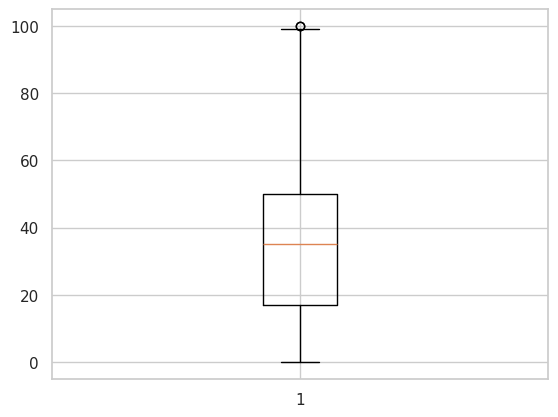

In [66]:
plt.boxplot(df["popularity"])
plt.show()

In [67]:
text_columns = ["artists", "album_name", "track_name", "track_genre"]

for col in text_columns:
    df[col] = (df[col].str.lower().str.strip())

In [68]:
df["track_genre"].unique

df["artists"].unique

<bound method Series.unique of 0                    gen hoshino
1                   ben woodward
2         ingrid michaelson;zayn
3                   kina grannis
4               chord overstreet
                   ...          
113995             rainy lullaby
113996             rainy lullaby
113997             cesária evora
113998          michael w. smith
113999             cesária evora
Name: artists, Length: 113999, dtype: object>

In [69]:
[df["duration_ms"] <= 0]

[0         False
 1         False
 2         False
 3         False
 4         False
           ...  
 113995    False
 113996    False
 113997    False
 113998    False
 113999    False
 Name: duration_ms, Length: 113999, dtype: bool]

## Doing EDA


In [70]:
df[["track_name", "tempo"]].head()

,track_name,tempo
0,comedy,87.917
1,ghost - acoustic,77.489
2,to begin again,76.332
3,can't help falling in love,181.740
4,hold on,119.949


In [71]:
# Top song Artist and Songs
df["artists"].value_counts().head(10)

artists
the beatles        279
george jones       271
stevie wonder      236
linkin park        224
ella fitzgerald    222
prateek kuhad      217
feid               202
chuck berry        190
håkan hellström    183
onerepublic        181
Name: count, dtype: int64

In [72]:
df["track_name"].value_counts().head(10)

track_name
run rudolph run                   151
halloween                          88
frosty the snowman                 84
little saint nick - 1991 remix     76
last last                          75
christmas time                     72
cómo se siente - remix             64
sleigh ride                        61
rumbatón                           60
x última vez                       58
Name: count, dtype: int64

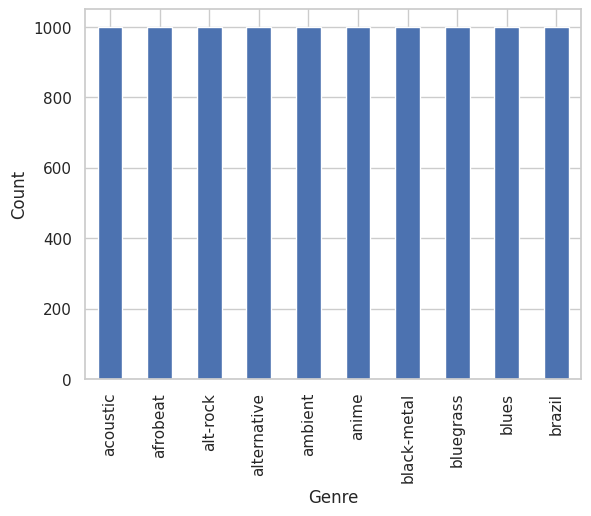

In [73]:
df["track_genre"].value_counts().head(10).plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

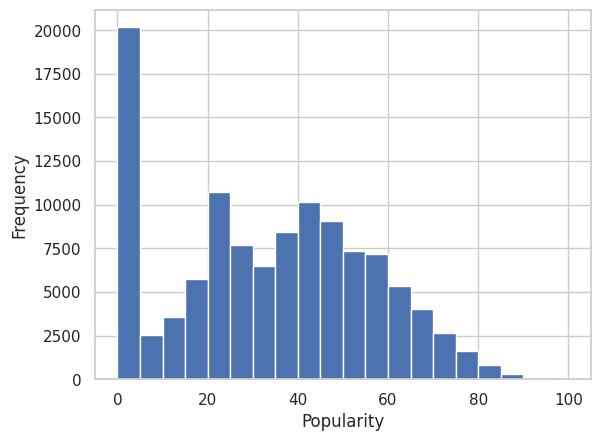

In [74]:
# popularity distribution

plt.hist(df["popularity"], bins=20)

plt.xlabel("Popularity")
plt.ylabel("Frequency")

plt.show()

In [75]:
(df["popularity"] == 0).sum()

np.int64(16019)

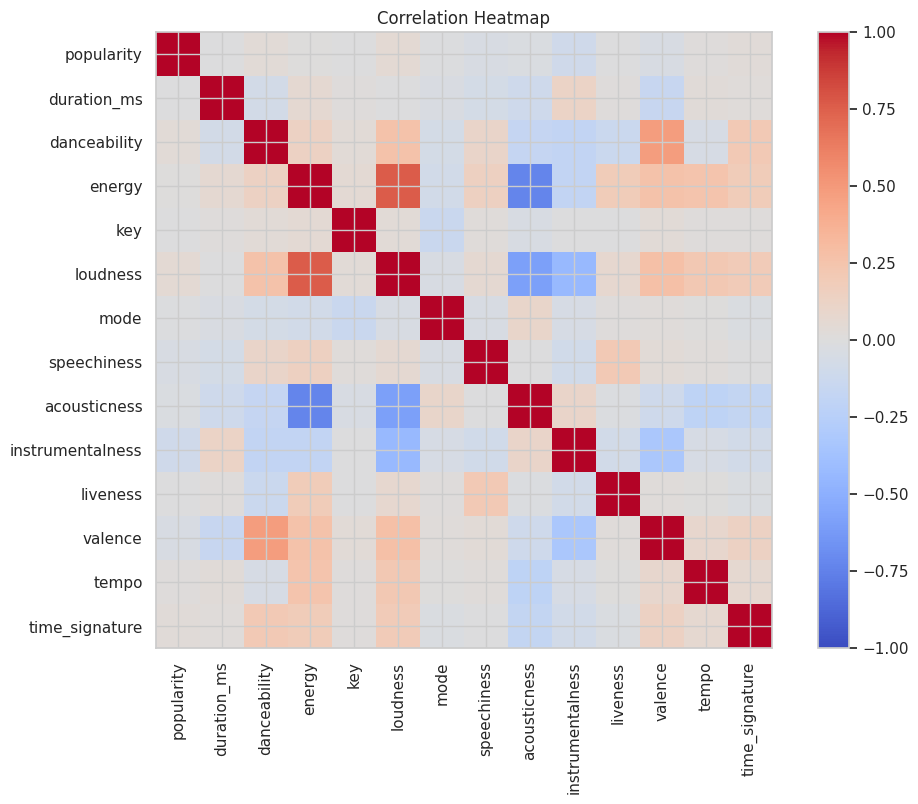

In [76]:
# Correlation heatmap
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.show()

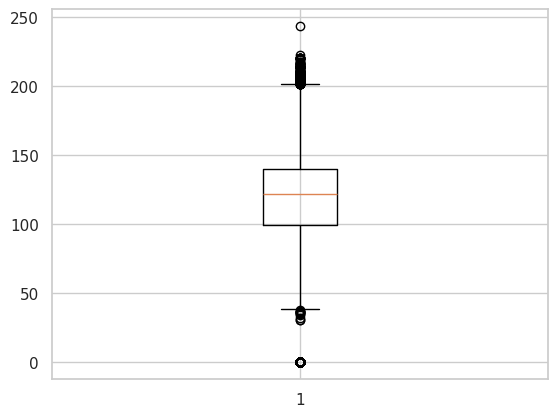

In [77]:
plt.boxplot(df["tempo"])
plt.show()

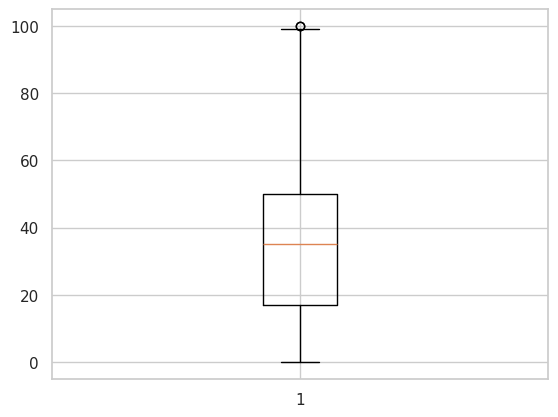

In [78]:
plt.boxplot(df["popularity"])
plt.show()

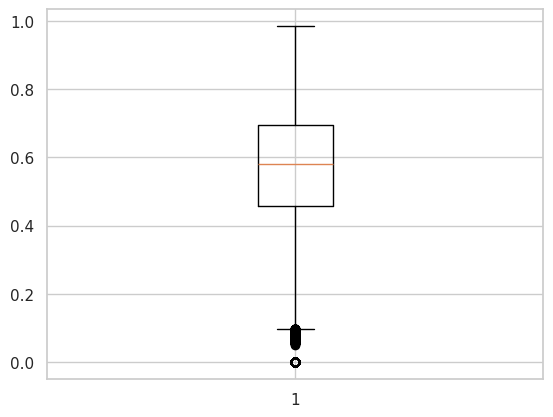

In [79]:
plt.boxplot(df["danceability"])
plt.show()

In [80]:
df["artists"].nunique()

31428

In [81]:
df["track_genre"].nunique()

114

In [82]:
df.sort_values(by="duration_ms", ascending=False).head(10)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
73617,tale of us,unity (voyage mix),unity (voyage mix) pt. 1,35,5237295,False,0.6950,0.736,5,-11.371,0,0.0374,0.00399,0.8600,0.0910,0.05090,124.001,4,minimal-techno
10935,timo maas,crossing wires 002 - compiled and mixed by tim...,crossing wires 002 - continuous dj mix,11,4789026,False,0.6970,0.632,1,-12.469,1,0.0451,0.00815,0.8710,0.0998,0.15100,121.055,4,breakbeat
10984,timo maas,crossing wires 002 - compiled and mixed by tim...,crossing wires 002 - continuous dj mix,11,4789026,False,0.6970,0.632,1,-12.469,1,0.0451,0.00815,0.8710,0.0998,0.15100,121.055,4,breakbeat
24348,seth troxler,seth troxler - the lab 03,the lab 03 - continuous dj mix part 1,8,4730302,False,0.6840,0.656,5,-11.163,0,0.0633,0.01910,0.8480,0.1030,0.30100,123.180,4,detroit-techno
73840,loco dice,amnesia ibiza - underground 10,amnesia ibiza underground 10 dj mix,17,4563897,False,0.7830,0.728,10,-10.176,0,0.0612,0.00158,0.8400,0.1580,0.18900,125.044,4,minimal-techno
13344,mark farina,house of om (dj mix),house of om - mark farina - continuous mix,11,4447520,False,0.8610,0.805,11,-6.461,0,0.0711,0.00548,0.5770,0.1350,0.54500,129.306,4,chicago-house
13245,mark farina,live in tokyo,live in tokyo - continuous mix,11,4339826,False,0.8060,0.582,1,-12.181,1,0.0874,0.00830,0.2370,0.3280,0.68600,128.368,4,chicago-house
13195,mark farina,greenhouse construction,greenhouse construction,12,4334721,False,0.8460,0.744,10,-9.260,0,0.0611,0.00371,0.3350,0.3130,0.53200,125.434,4,chicago-house
27926,lenzman;dan stezo,nq state of mind,"nq state of mind, vol. 1 - continuous dj mix",15,4246206,True,0.5930,0.924,1,-3.979,1,0.0899,0.00369,0.0221,0.5340,0.24200,173.938,4,drum-and-bass
101390,ocean sounds,ocean waves sounds to relax and sleep,ocean waves sounds,39,4120258,False,0.0797,0.995,1,-17.379,1,0.0612,0.93200,0.5620,0.3100,0.00001,84.788,3,sleep


In [83]:
df["duration_min"] = df["duration_ms"] / 1000 / 60

In [84]:
df["duration_min"].describe()

count    113999.000000
mean          3.800519
std           1.788268
min           0.143100
25%           2.901100
50%           3.548433
75%           4.358433
max          87.288250
Name: duration_min, dtype: float64

In [85]:
df.sort_values(by="duration_min", ascending=False).head(10)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
73617,tale of us,unity (voyage mix),unity (voyage mix) pt. 1,35,5237295,False,0.6950,0.736,5,-11.371,0,0.0374,0.00399,0.8600,0.0910,0.05090,124.001,4,minimal-techno,87.288250
10935,timo maas,crossing wires 002 - compiled and mixed by tim...,crossing wires 002 - continuous dj mix,11,4789026,False,0.6970,0.632,1,-12.469,1,0.0451,0.00815,0.8710,0.0998,0.15100,121.055,4,breakbeat,79.817100
10984,timo maas,crossing wires 002 - compiled and mixed by tim...,crossing wires 002 - continuous dj mix,11,4789026,False,0.6970,0.632,1,-12.469,1,0.0451,0.00815,0.8710,0.0998,0.15100,121.055,4,breakbeat,79.817100
24348,seth troxler,seth troxler - the lab 03,the lab 03 - continuous dj mix part 1,8,4730302,False,0.6840,0.656,5,-11.163,0,0.0633,0.01910,0.8480,0.1030,0.30100,123.180,4,detroit-techno,78.838367
73840,loco dice,amnesia ibiza - underground 10,amnesia ibiza underground 10 dj mix,17,4563897,False,0.7830,0.728,10,-10.176,0,0.0612,0.00158,0.8400,0.1580,0.18900,125.044,4,minimal-techno,76.064950
13344,mark farina,house of om (dj mix),house of om - mark farina - continuous mix,11,4447520,False,0.8610,0.805,11,-6.461,0,0.0711,0.00548,0.5770,0.1350,0.54500,129.306,4,chicago-house,74.125333
13245,mark farina,live in tokyo,live in tokyo - continuous mix,11,4339826,False,0.8060,0.582,1,-12.181,1,0.0874,0.00830,0.2370,0.3280,0.68600,128.368,4,chicago-house,72.330433
13195,mark farina,greenhouse construction,greenhouse construction,12,4334721,False,0.8460,0.744,10,-9.260,0,0.0611,0.00371,0.3350,0.3130,0.53200,125.434,4,chicago-house,72.245350
27926,lenzman;dan stezo,nq state of mind,"nq state of mind, vol. 1 - continuous dj mix",15,4246206,True,0.5930,0.924,1,-3.979,1,0.0899,0.00369,0.0221,0.5340,0.24200,173.938,4,drum-and-bass,70.770100
101390,ocean sounds,ocean waves sounds to relax and sleep,ocean waves sounds,39,4120258,False,0.0797,0.995,1,-17.379,1,0.0612,0.93200,0.5620,0.3100,0.00001,84.788,3,sleep,68.670967


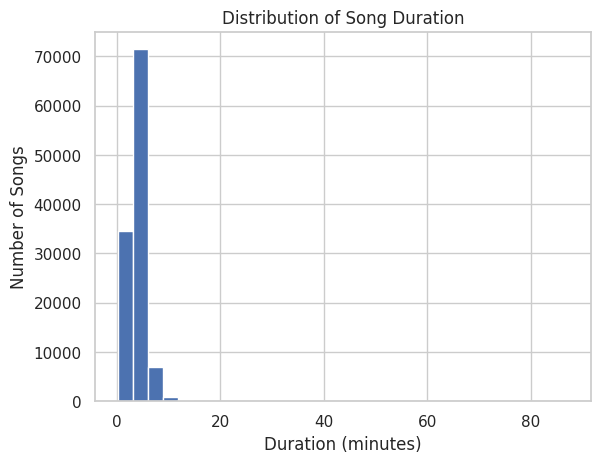

In [86]:
plt.hist(df["duration_min"], bins=30)
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Songs")
plt.title("Distribution of Song Duration")
plt.show()

In [87]:
df = df[df["duration_min"] <= 20]

In [88]:
df.isnull().sum()

artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
duration_min        0
dtype: int64

## Feature Engineering

In [89]:
df = df.drop_duplicates(subset=["track_name", "artists"],keep="first").reset_index(drop=True)

In [90]:
df["tags"] = (df["artists"] + " " + df["track_genre"])

In [91]:
tfidf = TfidfVectorizer()
text_vectors = tfidf.fit_transform(df["tags"])

In [92]:
features = ["energy", "tempo", "danceability", "valence", "acousticness", "speechiness", "loudness", "liveness", "instrumentalness"
""]

Scaling Features

In [93]:
scaler = StandardScaler()
rec_cols_vectors = scaler.fit_transform(df[features])

In [94]:
from scipy.sparse import hstack

combined_vectors = hstack([text_vectors, rec_cols_vectors])
combined_vectors = combined_vectors.tocsr()

In [104]:
def recommend(song_name, artist):
    song_name = song_name.lower().strip()
    artist = artist.lower().strip()

    song = df[
            (df["track_name"].str.lower().str.strip() == song_name) &
            (df["artists"].str.lower().str.strip() == artist)
        ]    
    
    if song.empty:
        print("Song not found!")
        return
    
    positional_index = df.index.get_loc(song.index[0])

    #compare only this song with others
    similarity_scores = cosine_similarity(
            combined_vectors[positional_index].reshape(1, -1), combined_vectors).flatten()
      
    top_indices = similarity_scores.argsort()[::-1][1:6]

    recommendations = df.iloc[top_indices][["track_name", "artists", "track_genre"]].copy()
    recommendations["similarity"] = (similarity_scores[top_indices] * 100).round(3)

    return recommendations

In [96]:
df.shape

(81134, 21)

In [103]:
recommend("can't help falling in love", "kina grannis")  # with extra spaces

,track_name,artists,track_genre,similarity
242,can't help falling in love - piano version,kina grannis,acoustic,0.985
45764,repetitious (zamaangard),baaroot,iranian,0.945
66436,uzun gecələr,rashid beibutov,romance,0.945
6802,in a sentimental mood,ella fitzgerald,blues,0.944
57569,"gianni schicchi: ""o mio babbino caro""",giacomo puccini;mirella freni;orchestra del ma...,opera,0.944


In [105]:
def search(query):   # query = whatever the user typed
    mask = (
        df["track_name"].str.contains(query, case=False, na=False) |
        df["artists"].str.contains(query, case=False, na=False)
    )
    return df[mask][["track_name", "artists"]].drop_duplicates().head(10)

In [109]:
search("one direction")

,track_name,artists
61088,night changes,one direction
61162,what makes you beautiful,one direction
61207,steal my girl,one direction
61324,drag me down,one direction
61354,story of my life,one direction


In [112]:
import joblib

joblib.dump(df, "df.pkl")
joblib.dump(combined_vectors, "combined_vectors.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']